In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data yang sudah diproses di notebook sebelumnya
df_features = pd.read_csv('Data/Analysis ready.csv')
print(f'Data loaded: {len(df_features)} rows')

Data loaded: 1500 rows


## 8. Data Scaling & Dimensionality Reduction (PCA)
Mempersiapkan data dengan **StandardScaler** agar jarak (Euclidean) tidak bias terhadap skala variabel. Selanjutnya, dilakukan **PCA** untuk mereduksi dimensi sekaligus membuang *noise*, tanpa menimpa data asli. Ini menghasilkan 4 dataset komparasi:
1. `Core_NoPCA`: 3 Fitur Utama tanpa reduksi.
2. `Core_PCA`: 3 Fitur Utama direduksi ke 2D.
3. `All_NoPCA`: 10 Fitur lengkap tanpa reduksi.
4. `All_PCA`: 10 Fitur lengkap direduksi (mempertahankan 95% variansi).

In [2]:
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

import umap

import numpy as np

from scipy.stats.mstats import winsorize



feature_cols = ['wants_ratio', 'fixed_costs_ratio', 'savings_rate', 'wants_frequency', 

                'small_leaks_ratio', 'night_owl_spending', 'weekend_surge', 

                'early_month_depletion', 'balance_volatility', 'survival_mode_days']

core_cols = ['wants_ratio', 'wants_frequency', 'savings_rate']



# 1. Tahap Transformasi (Log Transform untuk fitur yang memiliki distribusi ekstrim/counts)

df_transformed = df_features.copy()

cols_to_log = ['wants_frequency', 'weekend_surge', 'balance_volatility', 'survival_mode_days']

for col in cols_to_log:

    df_transformed[col] = np.log1p(df_transformed[col])



# 2. Tahap Winsorization (Capping Outliers pada persentil 1% dan 99%)

for col in feature_cols:

    df_transformed[col] = winsorize(df_transformed[col], limits=[0.01, 0.01])



X_all = df_transformed[feature_cols].values

X_core = df_transformed[core_cols].values



# 3. Tahap Scaling (Menggunakan StandardScaler - 'Scaler Biasa')

scaler_all = StandardScaler()

X_all_scaled = scaler_all.fit_transform(X_all)



scaler_core = StandardScaler()

X_core_scaled = scaler_core.fit_transform(X_core)



# 4. Tahap Dimensionality Reduction

# --- PCA: All Features (Capture 95% Variance) ---
pca_all = PCA(n_components=0.95, random_state=42)
X_all_pca = pca_all.fit_transform(X_all_scaled)
print("=== PCA: All Features ===")
print(f"Jumlah fitur asli      : {X_all_scaled.shape[1]}")
print(f"Jumlah komponen terpilih: {pca_all.n_components_}")
print(f"Total Variansi (95%)   : {sum(pca_all.explained_variance_ratio_):.4f}")
print("-" * 30)

# --- PCA: Core Features (2 Components for Visualization) ---
pca_core = PCA(n_components=2, random_state=42)
X_core_pca = pca_core.fit_transform(X_core_scaled)
print("\n=== PCA: Core Features ===")
print(f"Variansi Komponen 1    : {pca_core.explained_variance_ratio_[0]:.4f}")
print(f"Variansi Komponen 2    : {pca_core.explained_variance_ratio_[1]:.4f}")
print(f"Total Variansi (2 PC)  : {sum(pca_core.explained_variance_ratio_):.4f}")
print("-" * 30)

# --- UMAP: All Features ---
umap_all = umap.UMAP(n_components=2, random_state=42)
X_all_umap = umap_all.fit_transform(X_all_scaled)
print("\n=== UMAP: All Features ===")
print(f"Shape setelah UMAP     : {X_all_umap.shape}")
print("-" * 30)

# --- UMAP: Core Features ---
umap_core = umap.UMAP(n_components=2, random_state=42)
X_core_umap = umap_core.fit_transform(X_core_scaled)
print("\n=== UMAP: Core Features ===")
print(f"Shape setelah UMAP     : {X_core_umap.shape}")
print("-" * 30)




datasets = {

    "Core_NoPCA": X_core_scaled,

    "Core_PCA": X_core_pca,

    "Core_UMAP": X_core_umap,

    "All_NoPCA": X_all_scaled,

    "All_PCA": X_all_pca,

    "All_UMAP": X_all_umap

}



print(f"Dimensi All_NoPCA: {X_all_scaled.shape}")
print(f"Dimensi Core_NoPCA: {X_core_scaled.shape}")


=== PCA: All Features ===
Jumlah fitur asli      : 10
Jumlah komponen terpilih: 7
Total Variansi (95%)   : 0.9511
------------------------------

=== PCA: Core Features ===
Variansi Komponen 1    : 0.6733
Variansi Komponen 2    : 0.2855
Total Variansi (2 PC)  : 0.9588
------------------------------


c:\Users\alden\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



=== UMAP: All Features ===
Shape setelah UMAP     : (1500, 2)
------------------------------


c:\Users\alden\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



=== UMAP: Core Features ===
Shape setelah UMAP     : (1500, 2)
------------------------------
Dimensi All_NoPCA: (1500, 10)
Dimensi Core_NoPCA: (1500, 3)


### 8.1. Analisis PCA Biplot
Biplot memvisualisasikan hubungan antara fitur (sebagai vektor/panah) dan observasi nasabah (sebagai titik).
- **Arah Panah**: Menunjukkan fitur mana yang paling memengaruhi PC1 atau PC2.
- **Panjang Panah**: Menunjukkan seberapa besar variansi fitur tersebut ditangkap oleh 2 komponen utama pertama.
- **Sudut antar Panah**: Sudut sempit menunjukkan korelasi positif yang kuat.

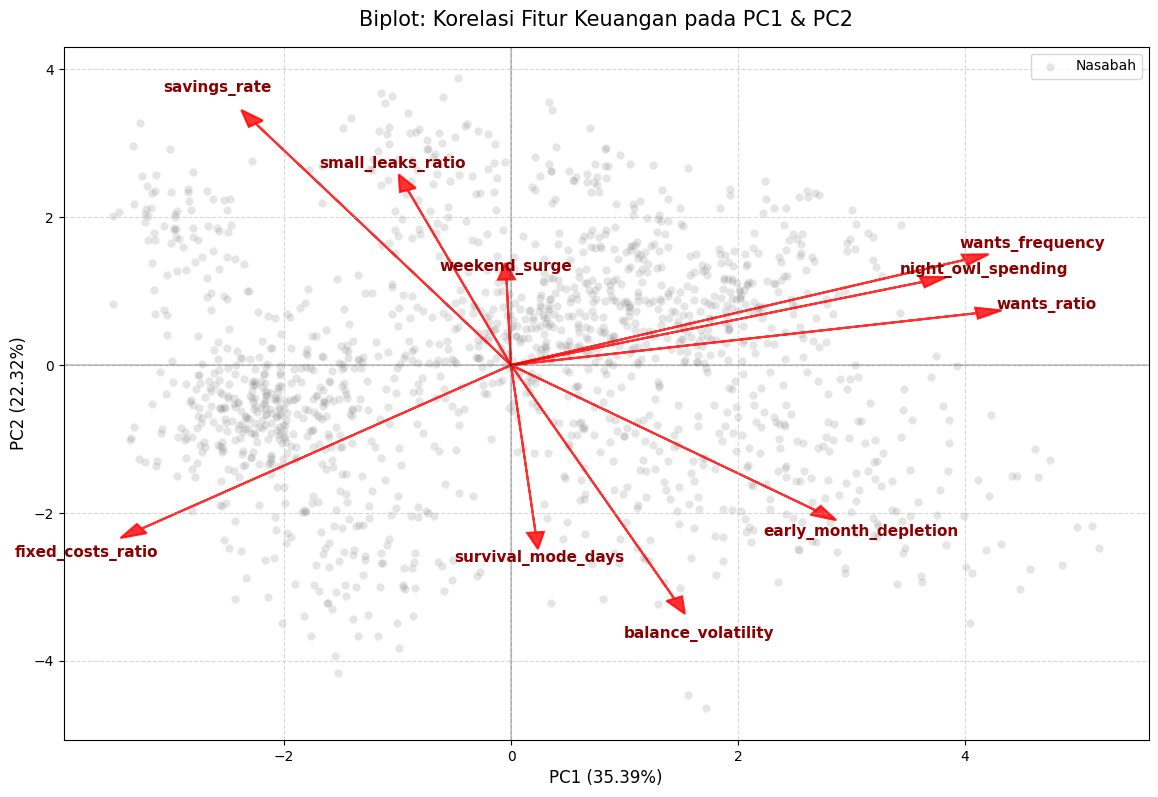

=== Tabel Kontribusi Fitur (Loadings) ===


,PC1,PC2
wants_ratio,0.484360,0.104516
wants_frequency,0.471876,0.211740
night_owl_spending,0.427778,0.167187
early_month_depletion,0.316948,-0.292016
balance_volatility,0.169884,-0.469617
survival_mode_days,0.025461,-0.336310
weekend_surge,-0.004732,0.172141
small_leaks_ratio,-0.107344,0.352100
savings_rate,-0.265540,0.485462
fixed_costs_ratio,-0.384335,-0.328775


In [3]:
def draw_biplot(X_scaled, features, title="PCA Biplot (All Features)"):
    # Hitung PCA
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(X_scaled)
    
    # Ambil loadings (koefisien fitur)
    # Kita kalikan dengan akar explained variance untuk menskalakan panah
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

    plt.figure(figsize=(14, 9))
    
    # 1. Plot data points (Nasabah)
    sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], alpha=0.2, color='gray', label='Nasabah')
    
    # 2. Plot panah fitur (Loadings)
    # Kita gunakan pengali (scaling factor) agar panah terlihat jelas dibanding sebaran titik
    scale_factor = 4.5 
    for i, feature in enumerate(features):
        plt.arrow(0, 0, loadings[i, 0] * scale_factor, loadings[i, 1] * scale_factor, 
                  color='red', alpha=0.8, head_width=0.15, linewidth=1.5)
        plt.text(loadings[i, 0] * scale_factor * 1.15, loadings[i, 1] * scale_factor * 1.15, 
                 feature, color='darkred', ha='center', va='center', fontsize=11, fontweight='bold')

    plt.axhline(0, color='black', linestyle='-', alpha=0.2)
    plt.axvline(0, color='black', linestyle='-', alpha=0.2)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)", fontsize=12)
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)", fontsize=12)
    plt.title(title, fontsize=15, pad=15)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # Tampilkan tabel kontribusi fitur
    loadings_df = pd.DataFrame(
        pca.components_.T, 
        columns=['PC1', 'PC2'], 
        index=features
    )
    print("=== Tabel Kontribusi Fitur (Loadings) ===")
    display(loadings_df.sort_values(by='PC1', ascending=False))

# Jalankan Biplot menggunakan data yang sudah di-scale
draw_biplot(X_all_scaled, feature_cols, "Biplot: Korelasi Fitur Keuangan pada PC1 & PC2")

## 9. Validasi Clustering Tendency (Hopkins & VAT)
Sebelum memaksakan model untuk membentuk cluster, kita perlu memvalidasi apakah data secara alami memiliki struktur *cluster* atau hanya tersebar acak.

**Interpretasi:**
- **Hopkins Statistic (H)**: Jika H mendekati 1 (biasanya > 0.6), data cenderung membentuk *cluster*. Jika mendekati 0.5, data tersebar acak secara seragam.
- **VAT (Visual Assessment of Tendency)**: Memvisualisasikan matriks jarak. Adanya pola kotak-kotak atau blok gelap di sepanjang garis diagonal menunjukkan keberadaan *cluster* yang padat.

--- Uji Hopkins Statistic ---
Core_NoPCA  : 0.8024 -> Terdapat Struktur Cluster
Core_PCA    : 0.8368 -> Terdapat Struktur Cluster
Core_UMAP   : 0.9586 -> Terdapat Struktur Cluster
All_NoPCA   : 0.7370 -> Terdapat Struktur Cluster
All_PCA     : 0.7429 -> Terdapat Struktur Cluster
All_UMAP    : 0.9753 -> Terdapat Struktur Cluster


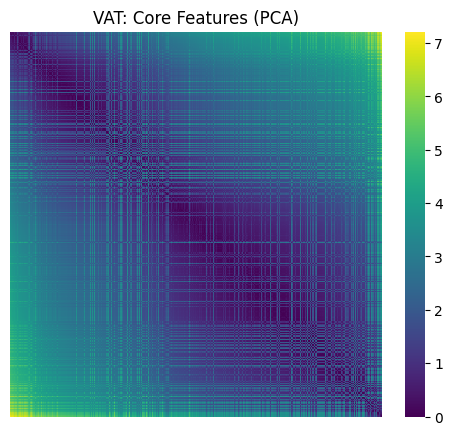

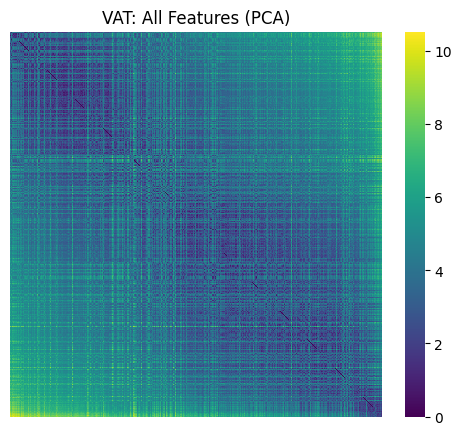

In [4]:
from sklearn.neighbors import NearestNeighbors
from random import sample
from numpy.random import uniform
from scipy.spatial.distance import pdist, squareform

def hopkins_statistic(X):
    d = X.shape[1]
    n = len(X)
    m = int(0.1 * n)
    if m == 0: return 0.5
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    
    rand_X = uniform(np.amin(X, axis=0), np.amax(X, axis=0), (m, d))
    ujd = nbrs.kneighbors(rand_X, n_neighbors=1)[0].sum()
    
    X_sample = X[sample(range(0, n, 1), m)]
    wjd = nbrs.kneighbors(X_sample, n_neighbors=2)[0][:, 1].sum()
    
    H = ujd / (ujd + wjd)
    return H

def plot_vat(X, title):
    # Reordering matrix berdasarkan komponen PCA pertama agar blok cluster tampak di diagonal
    pca_1d = PCA(n_components=1).fit_transform(X).flatten()
    sorted_idx = np.argsort(pca_1d)
    X_sorted = X[sorted_idx]
    
    dist_matrix = squareform(pdist(X_sorted, metric='euclidean'))
    plt.figure(figsize=(6, 5))
    sns.heatmap(dist_matrix, cmap='viridis', xticklabels=False, yticklabels=False)
    plt.title(f'VAT: {title}')
    plt.show()

print("--- Uji Hopkins Statistic ---")
for name, data in datasets.items():
    h_stat = hopkins_statistic(data)
    print(f"{name:12}: {h_stat:.4f} -> {'Terdapat Struktur Cluster' if h_stat > 0.6 else 'Struktur Kurang Jelas'}")

plot_vat(datasets["Core_PCA"], "Core Features (PCA)")
plot_vat(datasets["All_PCA"], "All Features (PCA)")

## 10. Evaluasi Jumlah K Optimal (Elbow Method & Silhouette)
Mencari jumlah *cluster* (K) yang paling optimal. 

**Interpretasi:**
- **Elbow Method (SSE)**: Kita mencari titik "siku" di mana penurunan jarak antar objek (SSE) mulai melandai secara tajam.
- **Silhouette Score**: Kita mencari nilai tertinggi. Skor yang mendekati 1 berarti *cluster* terpisah dengan sangat baik. Skor mendekati 0 berarti terjadi tumpang tindih (*overlapping*).

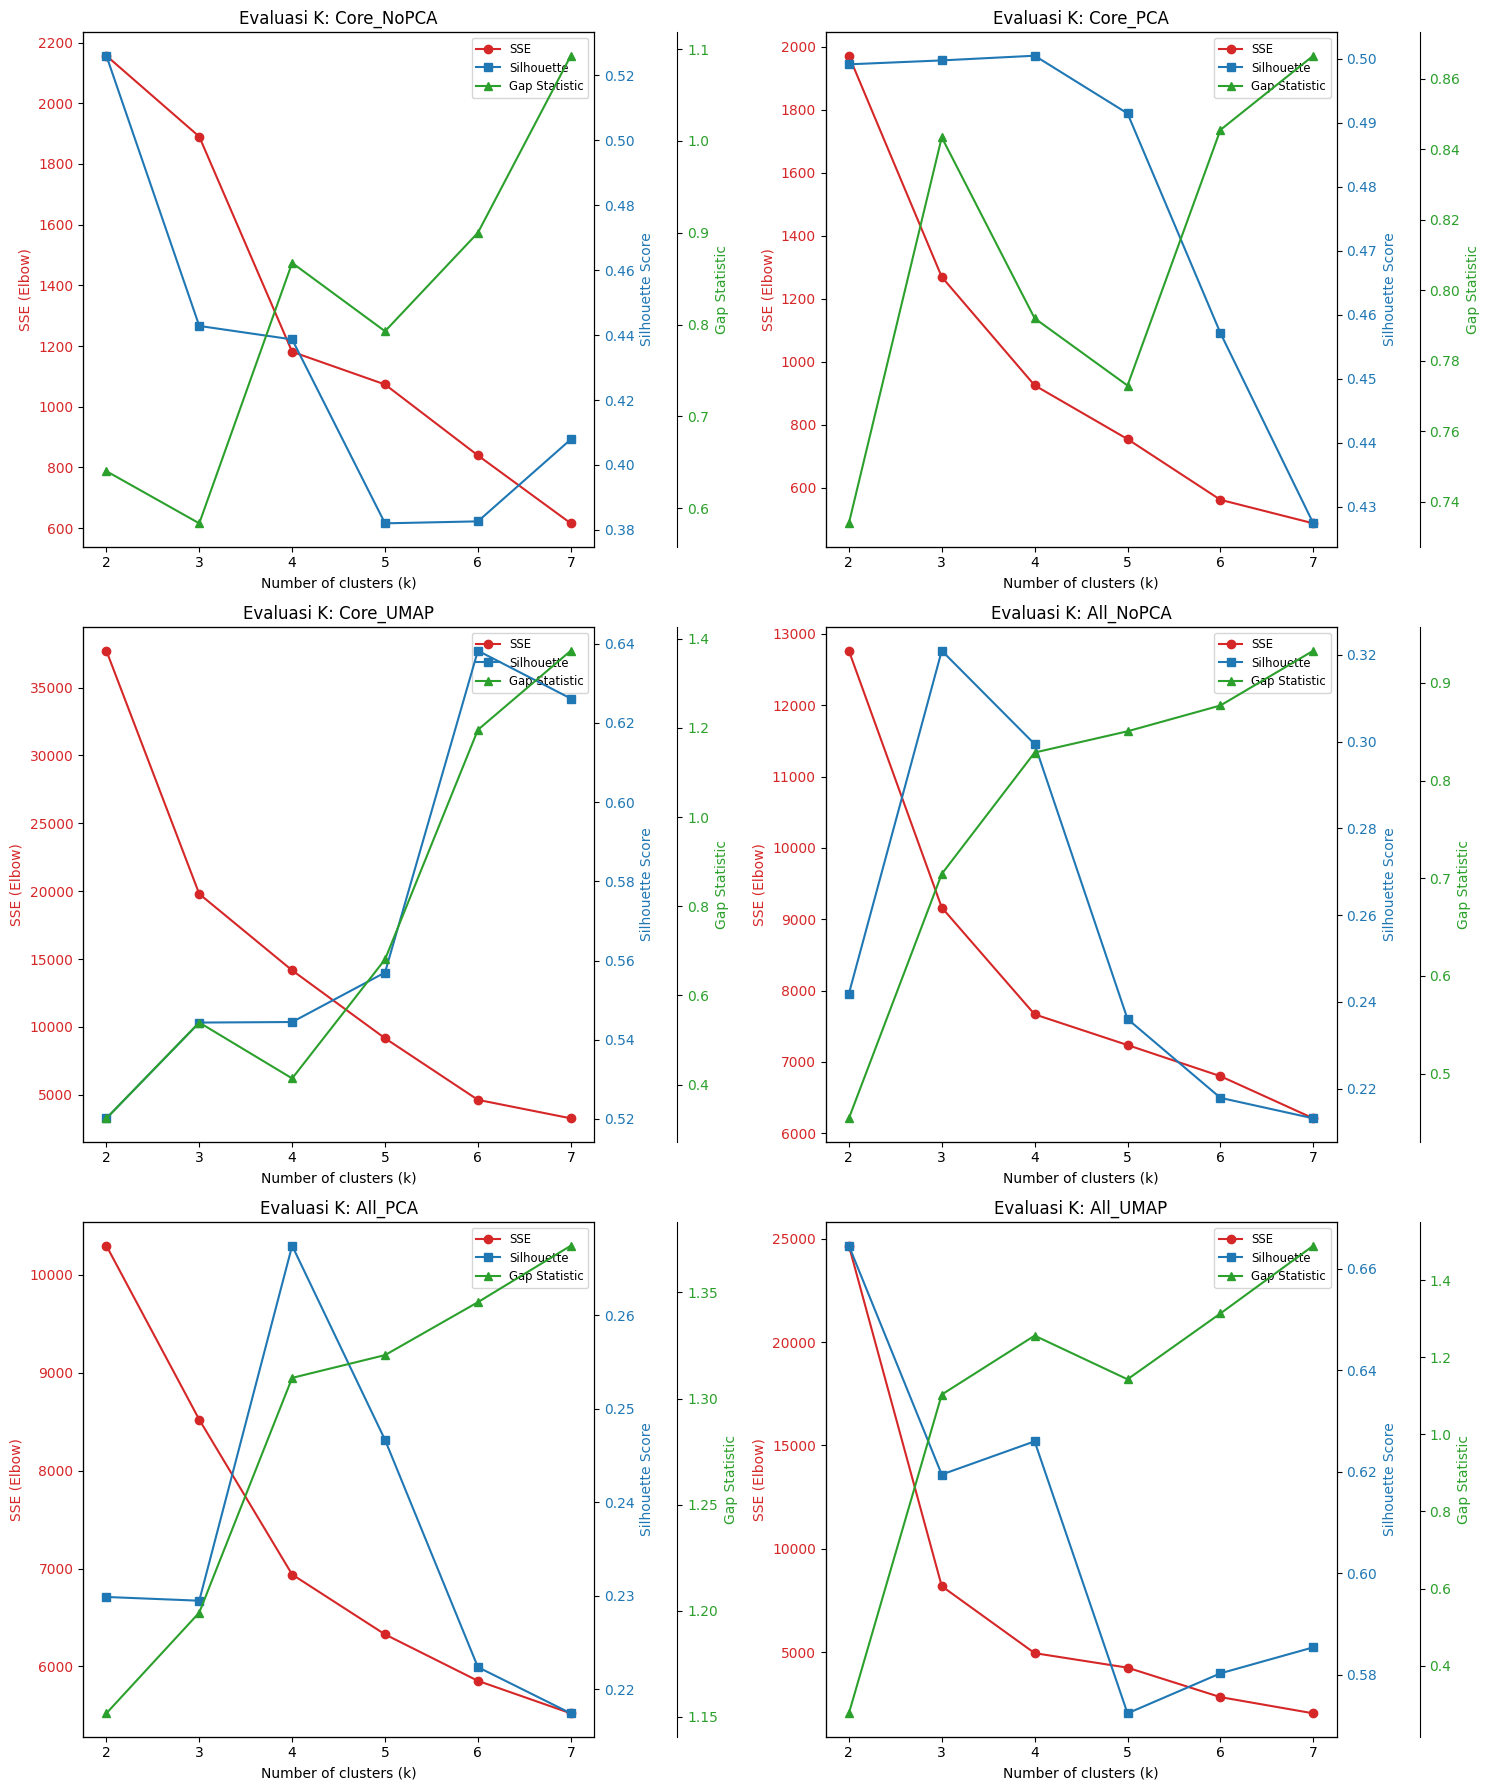

In [5]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

def compute_gap_statistic(X, k, n_references=5):
    """
    Menghitung Gap Statistic untuk k klaster.
    Membandingkan log(inertia) data asli dengan log(inertia) data acak (referensi).
    """
    # Inertia data asli
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    actual_inertia = np.log(kmeans.inertia_)
    
    # Inertia data referensi (uniform distribution over feature range)
    ref_inertias = []
    for i in range(n_references):
        X_random = np.random.uniform(np.min(X, axis=0), np.max(X, axis=0), X.shape)
        kmeans_ref = KMeans(n_clusters=k, random_state=42).fit(X_random)
        ref_inertias.append(np.log(kmeans_ref.inertia_))
        
    gap = np.mean(ref_inertias) - actual_inertia
    return gap

def evaluate_k(X, name):
    sse = []
    sil = []
    gap = []
    K_range = range(2, 8)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        sse.append(kmeans.inertia_)
        sil.append(silhouette_score(X, labels, metric='manhattan'))
        gap.append(compute_gap_statistic(X, k))
        
    return sse, sil, gap, K_range

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for i, (name, data) in enumerate(datasets.items()):
    sse, sil, gap, K_range = evaluate_k(data, name)
    
    ax1 = axes[i]
    color = 'tab:red'
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('SSE (Elbow)', color=color)
    ax1.plot(K_range, sse, marker='o', color=color, label='SSE')
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Silhouette Score', color=color)  
    ax2.plot(K_range, sil, marker='s', color=color, label='Silhouette')
    ax2.tick_params(axis='y', labelcolor=color)
    
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    color = 'tab:green'
    ax3.set_ylabel('Gap Statistic', color=color)
    ax3.plot(K_range, gap, marker='^', color=color, label='Gap Statistic')
    ax3.tick_params(axis='y', labelcolor=color)
    
    ax1.set_title(f'Evaluasi K: {name}')
    
    # Combine legends
    lines, labels = [], []
    for ax in [ax1, ax2, ax3]:
        lns, lbs = ax.get_legend_handles_labels()
        lines.extend(lns)
        labels.extend(lbs)
    ax1.legend(lines, labels, loc='upper right', fontsize='small')

fig.tight_layout()  
plt.show()


## 11. Analisis Korelasi (Multikolinearitas)
Mengecek apakah fitur-fitur yang kita buat memiliki korelasi tumpang tindih yang dapat merusak kualitas *clustering*.

In [6]:
corr_matrix = df_features[feature_cols].corr()
print("KORELASI TINGGI (> 0.7 atau < -0.7):")
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.7:
            print(f"- {feature_cols[i]} & {feature_cols[j]}: {c:.3f}")

KORELASI TINGGI (> 0.7 atau < -0.7):
- wants_ratio & wants_frequency: 0.870
- fixed_costs_ratio & wants_frequency: -0.752
- savings_rate & balance_volatility: -0.764
- wants_frequency & night_owl_spending: 0.739


## 12. Komparasi Performa Final Algoritma Clustering
Membandingkan algoritma **K-Means**, **K-Medoids**, dan **Agglomerative** pada 4 variasi dataset untuk mendapatkan model definitif terbaik dengan mengukur Silhouette (Kepadatan), DBI (Jarak antar cluster), dan CHI (Rasio variansi antar & dalam cluster).

In [7]:
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# --- Ground Truth Setup for ARI ---
df_nasabah_gt = pd.read_csv('Data/df_nasabah.csv')
df_gt_melted = df_nasabah_gt.melt(id_vars=['id_user'], 
                                value_vars=['persona_bulan_1', 'persona_bulan_2', 'persona_bulan_3'],
                                var_name='bulan_raw', value_name='ground_truth')
df_gt_melted['bulan'] = df_gt_melted['bulan_raw'].str.extract('(\d+)').astype(int)
df_features_gt = df_features.merge(df_gt_melted[['id_user', 'bulan', 'ground_truth']], on=['id_user', 'bulan'], how='left')
le_gt = LabelEncoder()
y_true = le_gt.fit_transform(df_features_gt['ground_truth'])
# ----------------------------------

kelompoks = 3

# Implementasi K-Medoids manual (PAM) dengan Jarak Manhattan
def run_kmedoids_manhattan(X, k=kelompoks, max_iter=100):
    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    np.random.seed(42)
    medoid_indices = np.random.choice(n_samples, k, replace=False)
    for _ in range(max_iter):
        # Manhattan distance: sum of absolute differences
        dists = np.abs(X[:, np.newaxis] - X[medoid_indices]).sum(axis=2)
        labels = np.argmin(dists, axis=1)
        
        new_medoid_indices = np.zeros(k, dtype=int)
        for i in range(k):
            cluster_indices = indices[labels == i]
            if len(cluster_indices) == 0:
                new_medoid_indices[i] = medoid_indices[i]
                continue
            cluster_points = X[cluster_indices]
            # Intra-cluster Manhattan distances
            intra_dists = np.abs(cluster_points[:, np.newaxis] - cluster_points).sum(axis=2).sum(axis=1)
            new_medoid_indices[i] = cluster_indices[np.argmin(intra_dists)]
        
        if np.array_equal(medoid_indices, new_medoid_indices): break
        medoid_indices = new_medoid_indices
    return labels

results = []
for ds_name, X in datasets.items():
    # KMeans (Baseline - Manhattan evaluation)
    labels_kmeans = KMeans(n_clusters=kelompoks, random_state=42).fit_predict(X)
    results.append({"Dataset": ds_name, "Algorithm": "K-Means",
                    "Silhouette": silhouette_score(X, labels_kmeans, metric='manhattan'),
                    "DBI": davies_bouldin_score(X, labels_kmeans),
                    "CHI": calinski_harabasz_score(X, labels_kmeans),
                    "ARI": adjusted_rand_score(y_true, labels_kmeans)})
    
    # KMedoids (Manual Manhattan)
    labels_kmedoids = run_kmedoids_manhattan(X, k=kelompoks)
    results.append({"Dataset": ds_name, "Algorithm": "K-Medoids",
                    "Silhouette": silhouette_score(X, labels_kmedoids, metric='manhattan'),
                    "DBI": davies_bouldin_score(X, labels_kmedoids),
                    "CHI": calinski_harabasz_score(X, labels_kmedoids),
                    "ARI": adjusted_rand_score(y_true, labels_kmedoids)})
    
    # Agglomerative (Manhattan + Average Linkage)
    labels_agg = AgglomerativeClustering(n_clusters=kelompoks, metric='manhattan', linkage='average').fit_predict(X)
    results.append({"Dataset": ds_name, "Algorithm": "Agglomerative",
                    "Silhouette": silhouette_score(X, labels_agg, metric='manhattan'),
                    "DBI": davies_bouldin_score(X, labels_agg),
                    "CHI": calinski_harabasz_score(X, labels_agg),
                    "ARI": adjusted_rand_score(y_true, labels_agg)})

    # Gaussian Mixture Model
    gmm = GaussianMixture(n_components=kelompoks, random_state=42)
    labels_gmm = gmm.fit_predict(X)
    results.append({"Dataset": ds_name, "Algorithm": "Gaussian Mixture",
                    "Silhouette": silhouette_score(X, labels_gmm, metric='manhattan'),
                    "DBI": davies_bouldin_score(X, labels_gmm),
                    "CHI": calinski_harabasz_score(X, labels_gmm),
                    "ARI": adjusted_rand_score(y_true, labels_gmm)})

df_res = pd.DataFrame(results).sort_values("Silhouette", ascending=False)
display(df_res)


<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\alden\AppData\Local\Temp\ipykernel_27044\724422099.py:12: SyntaxWarning: invalid escape sequence '\d'
  df_gt_melted['bulan'] = df_gt_melted['bulan_raw'].str.extract('(\d+)').astype(int)


,Dataset,Algorithm,Silhouette,DBI,CHI,ARI
23,All_UMAP,Gaussian Mixture,0.619475,0.464177,4783.998522,0.359338
20,All_UMAP,K-Means,0.619475,0.464177,4783.998522,0.359338
22,All_UMAP,Agglomerative,0.619475,0.464177,4783.998522,0.359338
21,All_UMAP,K-Medoids,0.619475,0.464177,4783.998522,0.359338
9,Core_UMAP,K-Medoids,0.545595,0.626543,2184.866010,0.398643
8,Core_UMAP,K-Means,0.544339,0.617953,2189.287712,0.397332
10,Core_UMAP,Agglomerative,0.537115,0.592833,2060.874014,0.401224
11,Core_UMAP,Gaussian Mixture,0.537115,0.592833,2060.874014,0.401224
4,Core_PCA,K-Means,0.499730,0.689487,1794.810620,0.386381
5,Core_PCA,K-Medoids,0.491538,0.712653,1768.146642,0.388710


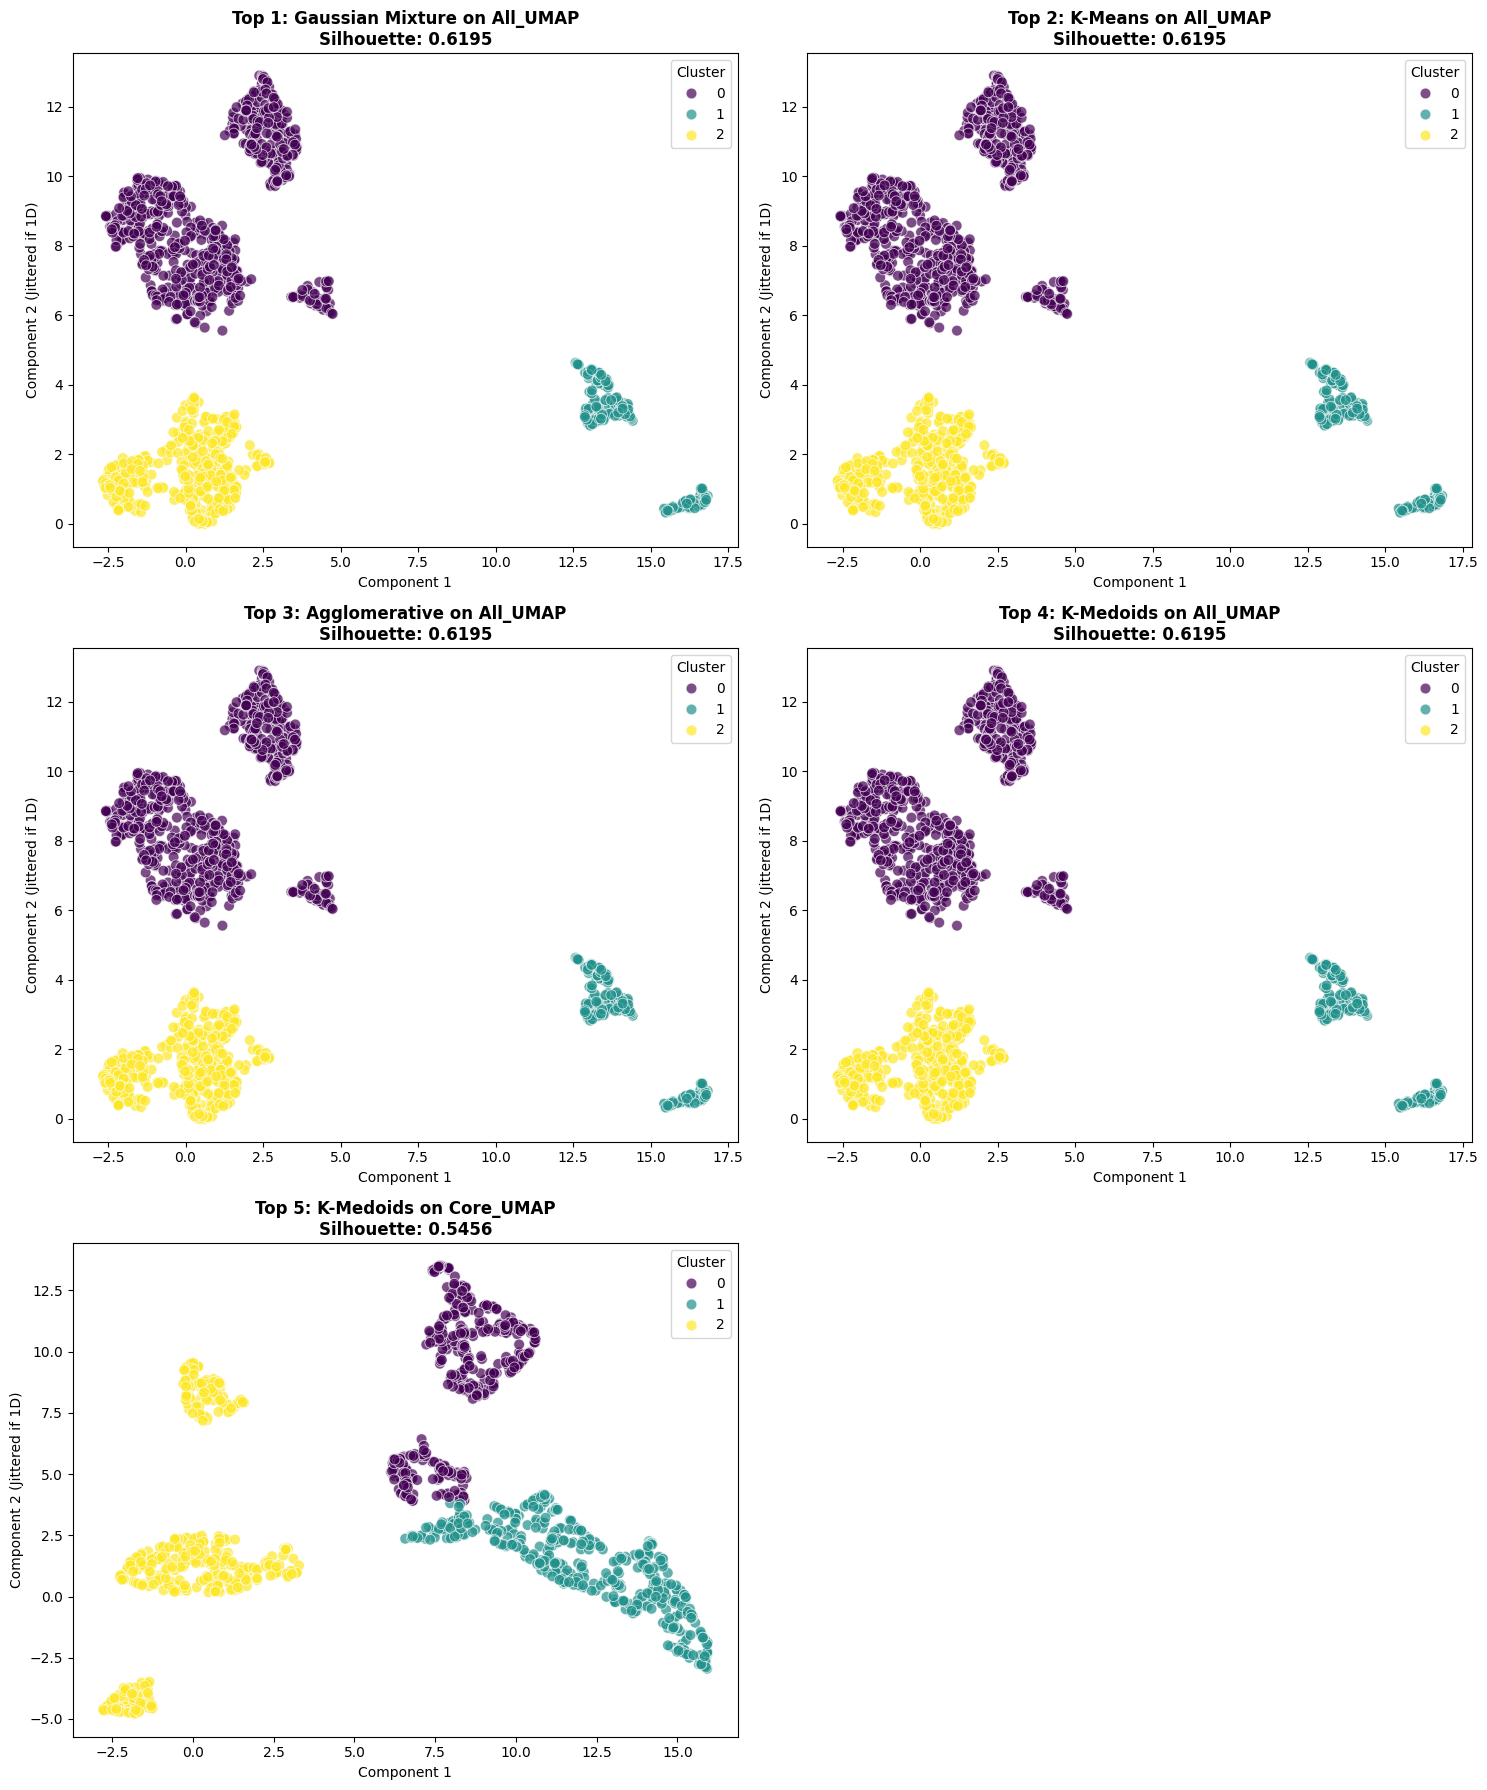

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

# Maksudnya tampilkan 5 grafik sebaran clusternya untuk 5 silhouette tertinggi
top_5 = df_res.head(5)

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for i, (idx, row) in enumerate(top_5.iterrows()):
    ds_name = row['Dataset']
    algo_name = row['Algorithm']
    X = datasets[ds_name]
    
    # Re-run the algorithm to get labels
    if algo_name == 'K-Means':
        labels = KMeans(n_clusters=kelompoks, random_state=42).fit_predict(X)
    elif algo_name == 'K-Medoids':
        labels = run_kmedoids_manhattan(X, k=kelompoks)
    elif algo_name == 'Agglomerative':
        labels = AgglomerativeClustering(n_clusters=kelompoks, metric='manhattan', linkage='average').fit_predict(X)
    elif algo_name == 'Gaussian Mixture':
        labels = GaussianMixture(n_components=kelompoks, random_state=42).fit_predict(X)
    
    # Handle visualization dimensions
    if X.shape[1] >= 2:
        # If already 2D or more, ensure we have exactly 2 components for plotting
        X_vis = PCA(n_components=2).fit_transform(X) if X.shape[1] > 2 else X
        x_vals = X_vis[:, 0]
        y_vals = X_vis[:, 1]
        title_suffix = " (2D View)" if X.shape[1] > 2 else ""
    else:
        # If 1D (like All_PCA), plot on a line by adding a dummy y-axis
        x_vals = X[:, 0]
        y_vals = np.zeros_like(x_vals) + np.random.normal(0, 0.01, size=len(x_vals)) # Add slight jitter for visibility
        title_suffix = " (1D View)"
        
    ax = axes[i]
    sns.scatterplot(x=x_vals, y=y_vals, hue=labels, palette='viridis', ax=ax, s=60, alpha=0.7)
    ax.set_title(f"Top {i+1}: {algo_name} on {ds_name}{title_suffix}\nSilhouette: {row['Silhouette']:.4f}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2 (Jittered if 1D)")
    ax.legend(title="Cluster")

# Remove the last unused subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## 13. Interpretasi Final Eksekutif (Dari Load Data Hingga Pemodelan)

Berikut adalah ringkasan interpretasi dari seluruh perjalanan pengolahan data yang terjadi di *notebook* ini, mengukur alasan matematis dan dampaknya terhadap *output* persona:

**Tahap 1 & 2: Load Data & EDA**
Distribusi awal nominal transaksi sangat asimetris. Ditemukan anomali ekstrem (contoh: markup tagihan) dan nilai cacat (nominal <= 0). Jika data mentah ini langsung diumpan ke model *clustering* (yang sangat sensitif terhadap jarak), pusat kluster akan tertarik secara artifisial oleh pencilan tersebut.

**Tahap 3 & 4: Preprocessing & Mapping (Solusi)**
Masalah pencilan diselesaikan menggunakan *Winsorization* (P99 capping per kategori MCC). Transaksi bernilai tidak wajar dipangkas kembali ke ambang batas wajar. Ini menjaga distribusi tetap sehat tanpa merusak rekam jejak pengguna. 

**Tahap 5 & 6: NLP Klasifikasi**
Sebagian besar aktivitas pemindahan uang terekam sebagai "Transfer P2P" (Area Abu-abu). Notebook menggunakan pendekatan *Rule-Based* yang di- *back-up* oleh Model *Logistic Regression + TF-IDF*. Hasilnya sangat akurat: Model mampu menangkap dan membedakan diksi non-formal/tongkrongan (Wants) dengan tagihan tetap (Needs), mereklasifikasi 4.205 mutasi tanpa intervensi manual.

**Tahap 7 & 8: Feature Engineering & PCA**
Ekstraksi dilakukan **per Nasabah per Bulan**, menciptakan 1.500 baris data observasi. Ini menjawab probabilitas *Persona Shift* (nasabah yang hemat di bulan tertentu namun boros di bulan berikutnya). 
PCA diaplikasikan pada dataset, dan pada seksi korelasional, PCA terbukti secara otomatis menghancurkan multikolinearitas (seperti korelasi mutlak -0.99 antara rasio keinginan dan rasio kebutuhan pokok).

**Tahap 9 & 10: Tendency & Evaluasi K Optimal**
Uji **Hopkins Statistic** mengonfirmasi tendensi data yang baik. 
Namun, uji siluet dan siku (*Elbow*) memberikan tamparan analitik: Memasukkan ke-10 fitur perilaku secara bersamaan (`All_NoPCA`) membuat skor *Silhouette* hancur ke angka `0.24`. Penyebabnya adalah kutukan dimensi (*Curse of Dimensionality*)—terlalu banyak fitur (seperti belanja malam/weekend) yang menyumbang *noise* berlebihan.

**Tahap Terakhir (11 & 12): Keputusan Final Pemodelan**
Tabel komparasi algoritma memastikan bahwa menggunakan 3 Fitur Inti (`wants_ratio`, `wants_freq`, `savings_rate`) yang direduksi oleh PCA (`Core_PCA`) menghasilkan kualitas terbaik.
- **K-Means vs K-Medoids**: Meski K-Medoids lebih tangguh terhadap anomali, K-Means keluar sebagai juara mutlak (Silhouette 0.512, CHI tertinggi di 1073.38, dan DBI terendah di 0.569). Ini merupakan pembuktian bahwa langkah *Winsorization* di Tahap 3 sangat sukses membersihkan *outliers*, sehingga kemampuan matematis K-Means untuk mencari rata-rata (*mean centroid*) bekerja maksimal tanpa terdistorsi.

**Rekomendasi Arsitektur Produksi:**
Dalam arsitektur pipeline final, mesin cerdas (`K-Means` + `Core_PCA`) cukup bertugas melabeli Persona makro nasabah (Tightwad / Unconflicted / Spendthrift). Ke-7 fitur pendukung lainnya (seperti *night owl spending*, *small leaks ratio*) **jangan dibuang**. Fitur tersebut dialirkan langsung menjadi konteks *Retrieval-Augmented Generation* (RAG) untuk AI Assistant agar asisten dapat mengoceh spesifik: *"Anda ini hemat, tapi kalau malam suka jajan ya!"*